## 给币安在2025/1/2单日的交易记录做EDA

### 导入数据

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw/binance/BTCUSDT/BTCUSDT-aggTrades-2025-01-02.csv")

cols = [
    "agg_trade_id",
    "price",
    "quantity",
    "first_trade_id",
    "last_trade_id",
    "timestamp",
    "is_buyer_maker",
    "is_best_match",
]

df = pd.read_csv(data_path, names=cols)

df.head()

,agg_trade_id,price,quantity,first_trade_id,last_trade_id,timestamp,is_buyer_maker,is_best_match
0,3359457659,94591.78,0.00015,4361451942,4361451942,1735776000113701,True,True
1,3359457660,94591.78,0.00181,4361451943,4361451943,1735776000174250,True,True
2,3359457661,94591.79,0.00092,4361451944,4361451944,1735776000539055,False,True
3,3359457662,94591.79,0.00231,4361451945,4361451945,1735776000540109,False,True
4,3359457663,94591.78,0.04822,4361451946,4361451946,1735776000638375,True,True


#### 查看数据格式

In [2]:
print("rows:", len(df))
print("columns:", df.columns.tolist())

df.info()

rows: 1299165
columns: ['agg_trade_id', 'price', 'quantity', 'first_trade_id', 'last_trade_id', 'timestamp', 'is_buyer_maker', 'is_best_match']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299165 entries, 0 to 1299164
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   agg_trade_id    1299165 non-null  int64  
 1   price           1299165 non-null  float64
 2   quantity        1299165 non-null  float64
 3   first_trade_id  1299165 non-null  int64  
 4   last_trade_id   1299165 non-null  int64  
 5   timestamp       1299165 non-null  int64  
 6   is_buyer_maker  1299165 non-null  bool   
 7   is_best_match   1299165 non-null  bool   
dtypes: bool(2), float64(2), int64(4)
memory usage: 61.9 MB


#### 给数据重新定义时间戳，增加可读性

In [3]:
df["time"] = pd.to_datetime(df["timestamp"], unit="us", utc=True)

print(df["time"].min())
print(df["time"].max())

df[["time", "price", "quantity", "is_buyer_maker"]].head()

2025-01-02 00:00:00.113701+00:00
2025-01-02 23:59:59.679660+00:00


,time,price,quantity,is_buyer_maker
0,2025-01-02 00:00:00.113701+00:00,94591.78,0.00015,True
1,2025-01-02 00:00:00.174250+00:00,94591.78,0.00181,True
2,2025-01-02 00:00:00.539055+00:00,94591.79,0.00092,False
3,2025-01-02 00:00:00.540109+00:00,94591.79,0.00231,False
4,2025-01-02 00:00:00.638375+00:00,94591.78,0.04822,True


#### 健康检查

In [4]:
print("missing values:")
print(df.isna().sum())

print("timestamp monotonic:", df["timestamp"].is_monotonic_increasing)
print("duplicate agg_trade_id:", df["agg_trade_id"].duplicated().sum())

print("price min/max:", df["price"].min(), df["price"].max())
print("quantity min/max:", df["quantity"].min(), df["quantity"].max())

missing values:
agg_trade_id      0
price             0
quantity          0
first_trade_id    0
last_trade_id     0
timestamp         0
is_buyer_maker    0
is_best_match     0
time              0
dtype: int64
timestamp monotonic: True
duplicate agg_trade_id: 0
price min/max: 94392.0 97839.5
quantity min/max: 1e-05 18.89042


#### 查看BTCUSDT一天内的交易节奏，并绘制图片

#### 先看相邻成交间隔的统计

zero dt rows: 720754
negative dt rows: 0


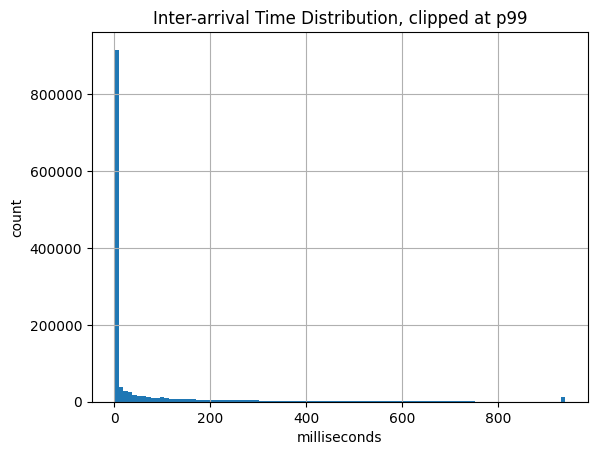

In [5]:
import matplotlib.pyplot as plt

df = df.sort_values("timestamp").reset_index(drop=True)

df["dt_us"] = df["timestamp"].diff()
df["dt_ms"] = df["dt_us"] / 1000

df["notional"] = df["price"] * df["quantity"]
df["taker_side"] = df["is_buyer_maker"].map({
    True: "sell",   # buyer 是挂单方，所以主动方是卖方
    False: "buy",   # buyer 是吃单方，所以主动方是买方
})

df["dt_ms"].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

print("zero dt rows:", (df["dt_us"] == 0).sum())
print("negative dt rows:", (df["dt_us"] < 0).sum())

clip_ms = df["dt_ms"].quantile(0.99)

df["dt_ms"].clip(upper=clip_ms).hist(bins=100)

plt.title("Inter-arrival Time Distribution, clipped at p99")
plt.xlabel("milliseconds")
plt.ylabel("count")
plt.show()

#### 每秒成交量

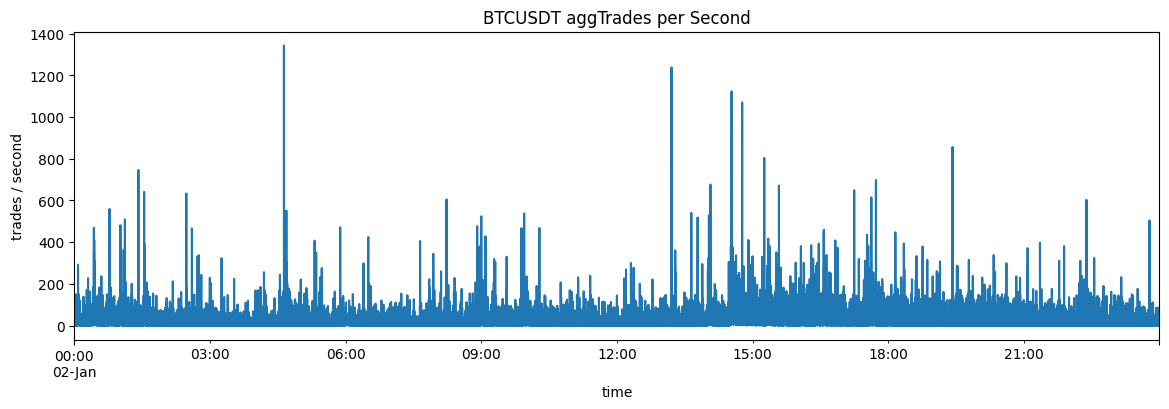

In [6]:
trades_per_sec = df.set_index("time").resample("1s").size()

trades_per_sec.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

trades_per_sec.plot(figsize=(14, 4))

plt.title("BTCUSDT aggTrades per Second")
plt.xlabel("time")
plt.ylabel("trades / second")
plt.show()

#### 美妙成交金额

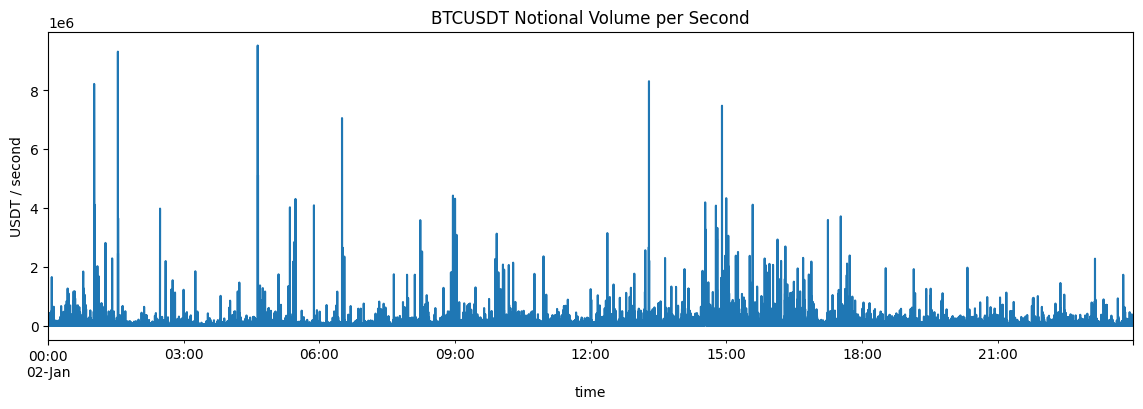

In [7]:
notional_per_sec = df.set_index("time")["notional"].resample("1s").sum()

notional_per_sec.plot(figsize=(14, 4))

plt.title("BTCUSDT Notional Volume per Second")
plt.xlabel("time")
plt.ylabel("USDT / second")
plt.show()

#### 重新定义dataframe

In [8]:
import numpy as np

df = df.sort_values("time").reset_index(drop=True)
df["notional"] = df["price"] * df["quantity"]
df["signed_quantity"] = np.where(
    df["is_buyer_maker"],
    -df["quantity"],   # 主动卖
    df["quantity"],    # 主动买
)

#### 1s聚合

In [9]:
g = df.set_index("time")

bars_1s = g.resample("1s").agg(
    price_open=("price", "first"),
    price_high=("price", "max"),
    price_low=("price", "min"),
    price_close=("price", "last"),
    volume=("quantity", "sum"),
    notional=("notional", "sum"),
    trade_count=("agg_trade_id", "count"),
    signed_volume=("signed_quantity", "sum"),
)

bars_1s["vwap"] = bars_1s["notional"] / bars_1s["volume"]
bars_1s["price_close"] = bars_1s["price_close"].ffill()
bars_1s["return_1s"] = bars_1s["price_close"].pct_change()

bars_1s.head()

,price_open,price_high,price_low,price_close,volume,notional,trade_count,signed_volume,vwap,return_1s
time,,,,,,,,,,
2025-01-02 00:00:00+00:00,94591.78,94591.79,94591.78,94591.79,0.12408,11736.948500,19,-0.03648,94591.783530,NaN
2025-01-02 00:00:01+00:00,94591.79,94591.79,94591.78,94591.79,0.04734,4477.974929,7,-0.03456,94591.781350,0.0
2025-01-02 00:00:02+00:00,94591.78,94591.79,94591.78,94591.79,0.09190,8692.985005,6,-0.00720,94591.784608,0.0
2025-01-02 00:00:03+00:00,94591.78,94591.79,94591.78,94591.79,0.03234,3059.098464,7,0.02736,94591.789230,0.0
2025-01-02 00:00:04+00:00,94591.79,94591.79,94591.79,94591.79,0.01300,1229.693270,5,0.01300,94591.790000,0.0


In [10]:
# 标签

horizon = 1
threshold = 0.0001  # 1 bp = 0.01%

bars_1s["future_price"] = bars_1s["price_close"].shift(-horizon)
bars_1s["future_return"] = bars_1s["future_price"] / bars_1s["price_close"] - 1

bars_1s["label_1s"] = 0
bars_1s.loc[bars_1s["future_return"] > threshold, "label_1s"] = 1
bars_1s.loc[bars_1s["future_return"] < -threshold, "label_1s"] = -1

bars_1s["label_1s"].value_counts(normalize=True).sort_index()

label_1s
-1    0.045104
 0    0.909039
 1    0.045856
Name: proportion, dtype: float64

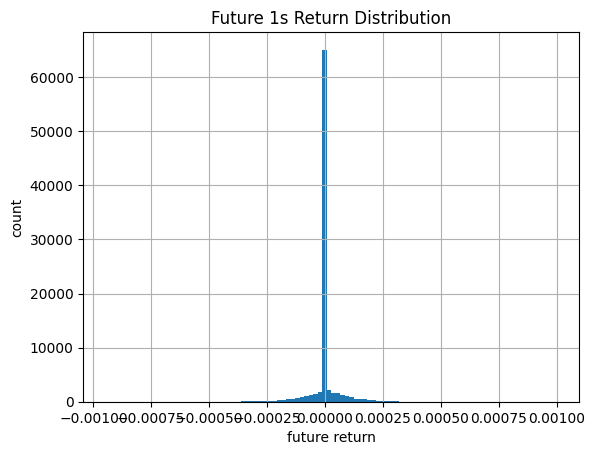

In [11]:
bars_1s["future_return"].dropna().clip(-0.001, 0.001).hist(bins=100)

plt.title("Future 1s Return Distribution")
plt.xlabel("future return")
plt.ylabel("count")
plt.show()

In [12]:
for horizon in [1, 5, 10, 30, 60]:
    for threshold in [0.00001, 0.00002, 0.00005, 0.0001]:
        fr = bars_1s["price_close"].shift(-horizon) / bars_1s["price_close"] - 1

        label = pd.Series(0, index=bars_1s.index)
        label[fr > threshold] = 1
        label[fr < -threshold] = -1

        dist = label.value_counts(normalize=True).reindex([-1, 0, 1], fill_value=0)
        print(
            f"h={horizon:>2}s th={threshold:.5f} | "
            f"down={dist[-1]:.3f}, flat={dist[0]:.3f}, up={dist[1]:.3f}"
        )

h= 1s th=0.00001 | down=0.119, flat=0.755, up=0.126
h= 1s th=0.00002 | down=0.108, flat=0.778, up=0.114
h= 1s th=0.00005 | down=0.080, flat=0.836, up=0.083
h= 1s th=0.00010 | down=0.045, flat=0.909, up=0.046
h= 5s th=0.00001 | down=0.276, flat=0.438, up=0.286
h= 5s th=0.00002 | down=0.263, flat=0.465, up=0.272
h= 5s th=0.00005 | down=0.223, flat=0.547, up=0.230
h= 5s th=0.00010 | down=0.160, flat=0.676, up=0.164
h=10s th=0.00001 | down=0.352, flat=0.284, up=0.364
h=10s th=0.00002 | down=0.339, flat=0.311, up=0.350
h=10s th=0.00005 | down=0.298, flat=0.394, up=0.308
h=10s th=0.00010 | down=0.231, flat=0.533, up=0.236
h=30s th=0.00001 | down=0.447, flat=0.097, up=0.457
h=30s th=0.00002 | down=0.435, flat=0.118, up=0.447
h=30s th=0.00005 | down=0.405, flat=0.180, up=0.415
h=30s th=0.00010 | down=0.345, flat=0.299, up=0.356
h=60s th=0.00001 | down=0.470, flat=0.041, up=0.489
h=60s th=0.00002 | down=0.463, flat=0.055, up=0.482
h=60s th=0.00005 | down=0.436, flat=0.103, up=0.460
h=60s th=0.0

h= 1s th=0.00001 (0.1 bp) | down=0.119, flat=0.755, up=0.126
h= 1s th=0.00002 (0.2 bp) | down=0.108, flat=0.778, up=0.114
h= 1s th=0.00005 (0.5 bp) | down=0.080, flat=0.836, up=0.083
h= 1s th=0.00010 (1.0 bp) | down=0.045, flat=0.909, up=0.046
h= 5s th=0.00001 (0.1 bp) | down=0.276, flat=0.438, up=0.286
h= 5s th=0.00002 (0.2 bp) | down=0.263, flat=0.465, up=0.272
h= 5s th=0.00005 (0.5 bp) | down=0.223, flat=0.547, up=0.230
h= 5s th=0.00010 (1.0 bp) | down=0.160, flat=0.676, up=0.164
h=10s th=0.00001 (0.1 bp) | down=0.352, flat=0.284, up=0.364
h=10s th=0.00002 (0.2 bp) | down=0.339, flat=0.311, up=0.350
h=10s th=0.00005 (0.5 bp) | down=0.298, flat=0.394, up=0.308
h=10s th=0.00010 (1.0 bp) | down=0.231, flat=0.533, up=0.236
h=30s th=0.00001 (0.1 bp) | down=0.447, flat=0.096, up=0.457
h=30s th=0.00002 (0.2 bp) | down=0.436, flat=0.118, up=0.447
h=30s th=0.00005 (0.5 bp) | down=0.405, flat=0.180, up=0.415
h=30s th=0.00010 (1.0 bp) | down=0.345, flat=0.299, up=0.356
h=60s th=0.00001 (0.1 bp

,horizon_s,threshold_bp,down_ratio,flat_ratio,up_ratio,abs_return_median,abs_return_p95,abs_return_p99
0,1,0.1,0.119434,0.754638,0.125927,1.032839e-07,0.000148,0.000283
1,1,0.2,0.108045,0.778354,0.113601,1.032839e-07,0.000148,0.000283
2,1,0.5,0.080429,0.836341,0.083230,1.032839e-07,0.000148,0.000283
3,1,1.0,0.045105,0.909038,0.045857,1.032839e-07,0.000148,0.000283
4,5,0.1,0.276069,0.437734,0.286197,3.273270e-05,0.000373,0.000647
5,5,0.2,0.263048,0.465085,0.271868,3.273270e-05,0.000373,0.000647
6,5,0.5,0.223034,0.547416,0.229550,3.273270e-05,0.000373,0.000647
7,5,1.0,0.159847,0.676150,0.164003,3.273270e-05,0.000373,0.000647
8,10,0.1,0.351869,0.283829,0.364301,8.734366e-05,0.000538,0.000911
9,10,0.2,0.338963,0.310696,0.350341,8.734366e-05,0.000538,0.000911


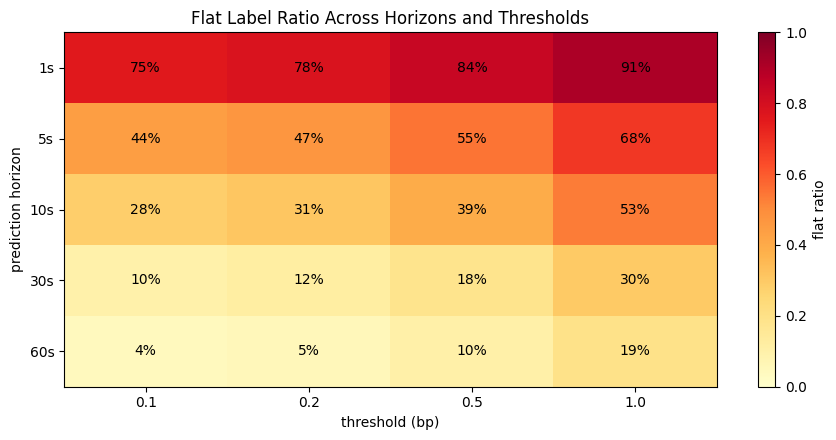

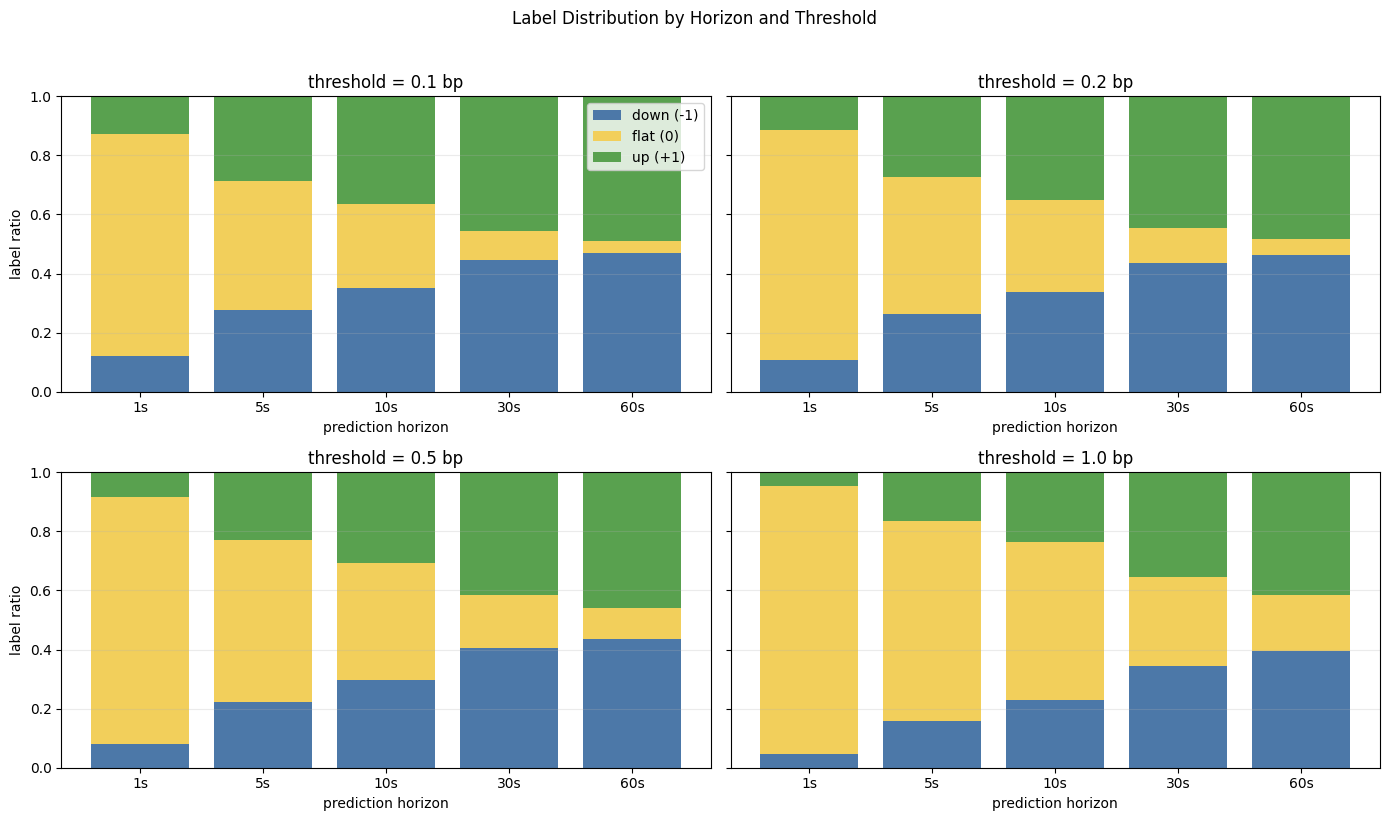

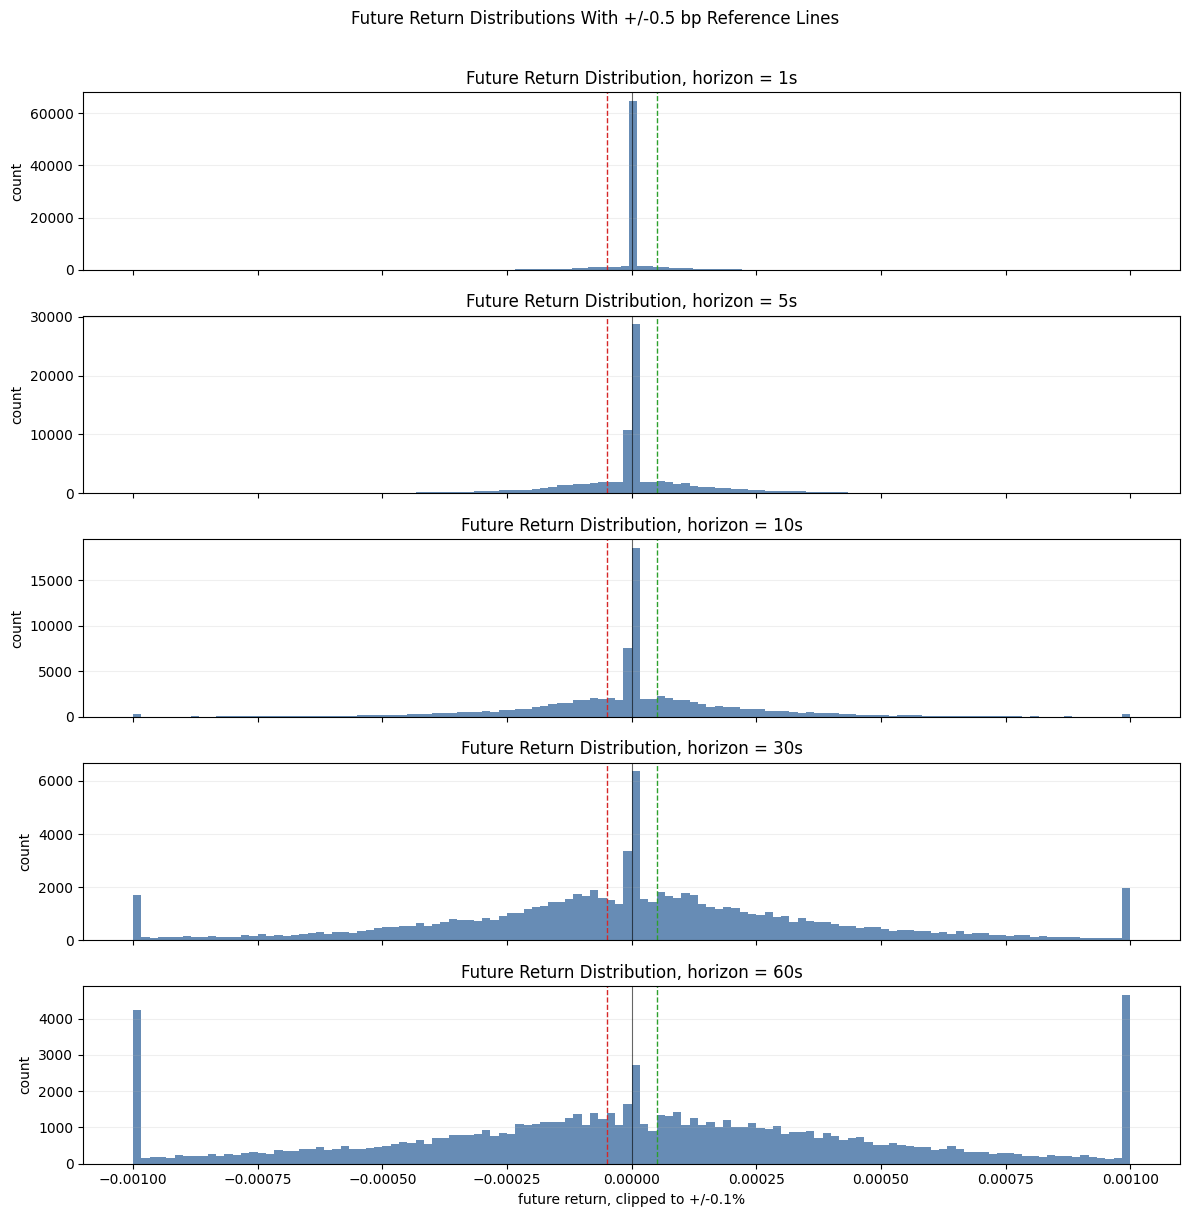

,horizon_s,threshold_bp,down_ratio,flat_ratio,up_ratio,up_down_gap,flat_target_gap,score
10,10,0.5,0.298241,0.393541,0.308219,0.009978,0.006459,0.016437
4,5,0.1,0.276069,0.437734,0.286197,0.010128,0.037734,0.047862
5,5,0.2,0.263048,0.465085,0.271868,0.008820,0.065085,0.073905
9,10,0.2,0.338963,0.310696,0.350341,0.011379,0.089304,0.100683
15,30,1.0,0.345282,0.298970,0.355749,0.010467,0.101030,0.111497
8,10,0.1,0.351869,0.283829,0.364301,0.012432,0.116171,0.128603
11,10,1.0,0.230675,0.532863,0.236463,0.005788,0.132863,0.138650
6,5,0.5,0.223034,0.547416,0.229550,0.006517,0.147416,0.153933
19,60,1.0,0.393908,0.192379,0.413713,0.019805,0.207621,0.227426
14,30,0.5,0.405118,0.180178,0.414704,0.009587,0.219822,0.229408


In [13]:
# Systematic label scan + Matplotlib visualizations

horizons = [1, 5, 10, 30, 60]  # seconds, because bars_1s uses 1-second bars
thresholds = [0.00001, 0.00002, 0.00005, 0.0001]  # 0.1 / 0.2 / 0.5 / 1.0 bp

scan_rows = []

for horizon in horizons:
    fr = bars_1s["price_close"].shift(-horizon) / bars_1s["price_close"] - 1
    valid_fr = fr.dropna()

    for threshold in thresholds:
        label = pd.Series(0, index=valid_fr.index)
        label[valid_fr > threshold] = 1
        label[valid_fr < -threshold] = -1

        counts = label.value_counts().reindex([-1, 0, 1], fill_value=0)
        props = label.value_counts(normalize=True).reindex([-1, 0, 1], fill_value=0)

        scan_rows.append({
            "horizon_s": horizon,
            "threshold": threshold,
            "threshold_bp": threshold * 10000,
            "down_count": counts[-1],
            "flat_count": counts[0],
            "up_count": counts[1],
            "down_ratio": props[-1],
            "flat_ratio": props[0],
            "up_ratio": props[1],
            "abs_return_median": valid_fr.abs().median(),
            "abs_return_p95": valid_fr.abs().quantile(0.95),
            "abs_return_p99": valid_fr.abs().quantile(0.99),
        })

scan_df = pd.DataFrame(scan_rows)

for row in scan_df.itertuples(index=False):
    print(
        f"h={row.horizon_s:>2}s th={row.threshold:.5f} ({row.threshold_bp:.1f} bp) | "
        f"down={row.down_ratio:.3f}, flat={row.flat_ratio:.3f}, up={row.up_ratio:.3f}"
    )

display(scan_df[[
    "horizon_s", "threshold_bp", "down_ratio", "flat_ratio", "up_ratio",
    "abs_return_median", "abs_return_p95", "abs_return_p99",
]])

# 1. Heatmap: flat label ratio
flat_pivot = scan_df.pivot(index="horizon_s", columns="threshold_bp", values="flat_ratio")

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(flat_pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(len(flat_pivot.columns)))
ax.set_xticklabels([f"{x:.1f}" for x in flat_pivot.columns])
ax.set_yticks(range(len(flat_pivot.index)))
ax.set_yticklabels([f"{int(x)}s" for x in flat_pivot.index])
ax.set_xlabel("threshold (bp)")
ax.set_ylabel("prediction horizon")
ax.set_title("Flat Label Ratio Across Horizons and Thresholds")

for i, horizon in enumerate(flat_pivot.index):
    for j, threshold_bp in enumerate(flat_pivot.columns):
        value = flat_pivot.loc[horizon, threshold_bp]
        ax.text(j, i, f"{value:.0%}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="flat ratio")
plt.tight_layout()
plt.show()

# 2. Stacked bars: down / flat / up ratios
threshold_values = sorted(scan_df["threshold_bp"].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.ravel()

for ax, threshold_bp in zip(axes, threshold_values):
    sub = scan_df[scan_df["threshold_bp"] == threshold_bp].sort_values("horizon_s")
    x = np.arange(len(sub))

    ax.bar(x, sub["down_ratio"], label="down (-1)", color="#4c78a8")
    ax.bar(x, sub["flat_ratio"], bottom=sub["down_ratio"], label="flat (0)", color="#f2cf5b")
    ax.bar(
        x,
        sub["up_ratio"],
        bottom=sub["down_ratio"] + sub["flat_ratio"],
        label="up (+1)",
        color="#59a14f",
    )

    ax.set_title(f"threshold = {threshold_bp:.1f} bp")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(h)}s" for h in sub["horizon_s"]])
    ax.set_xlabel("prediction horizon")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("label ratio")
axes[2].set_ylabel("label ratio")
axes[0].legend(loc="upper right")
fig.suptitle("Label Distribution by Horizon and Threshold", y=1.02)
plt.tight_layout()
plt.show()

# 3. Future return distributions by horizon
plot_horizons = [1, 5, 10, 30, 60]
reference_threshold = 0.00005  # 0.5 bp candidate threshold

fig, axes = plt.subplots(len(plot_horizons), 1, figsize=(12, 12), sharex=True)

for ax, horizon in zip(axes, plot_horizons):
    fr = bars_1s["price_close"].shift(-horizon) / bars_1s["price_close"] - 1
    clipped = fr.dropna().clip(-0.001, 0.001)

    ax.hist(clipped, bins=120, color="#4c78a8", alpha=0.85)
    ax.axvline(-reference_threshold, color="#d62728", linestyle="--", linewidth=1)
    ax.axvline(reference_threshold, color="#2ca02c", linestyle="--", linewidth=1)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(f"Future Return Distribution, horizon = {horizon}s")
    ax.set_ylabel("count")
    ax.grid(axis="y", alpha=0.2)

axes[-1].set_xlabel("future return, clipped to +/-0.1%")
fig.suptitle("Future Return Distributions With +/-0.5 bp Reference Lines", y=1.01)
plt.tight_layout()
plt.show()

# 4. Candidate combinations
candidate_df = scan_df.copy()
candidate_df["up_down_gap"] = (candidate_df["up_ratio"] - candidate_df["down_ratio"]).abs()
candidate_df["flat_target_gap"] = (candidate_df["flat_ratio"] - 0.4).abs()
candidate_df["score"] = candidate_df["flat_target_gap"] + candidate_df["up_down_gap"]

candidate_df = candidate_df.sort_values("score")

display(candidate_df[[
    "horizon_s", "threshold_bp", "down_ratio", "flat_ratio", "up_ratio",
    "up_down_gap", "flat_target_gap", "score",
]].head(10))